# PTB-XL ECG 1D CNN Training
## CardioFusion-XAI

This notebook trains the **1D CNN baseline** for the PTB-XL ECG modality.

The ECG preprocessing and train/validation/test split are reused from the
existing CardioFusion-XAI PTB-XL preprocessing pipeline.

The model architecture is adapted from the uploaded PTB-XL 1D CNN Kaggle
notebook. Only the ECG branch is used; the Kaggle notebook's metadata branch
is intentionally excluded so that this model can be fairly compared with
the other ECG-only architectures.

Diagnostic targets:

- NORM
- MI
- STTC
- CD
- HYP

The test set remains untouched until final evaluation.


In [9]:

from pathlib import Path
import copy
import json
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("PyTorch:", torch.__version__)


PyTorch: 2.14.0+cu130


In [10]:

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA: 13.0


In [11]:

SEED = 42


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print("Seed:", SEED)


Seed: 42


In [12]:

# Find the project root robustly instead of depending on the notebook
# launch directory.

current = Path.cwd()

PROJECT_ROOT = None

for path in [current, *current.parents]:
    if (path / "src").is_dir() and (path / "data").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find CardioFusion-XAI project root. "
        "The root must contain both 'src' and 'data'."
    )

PREPROCESSING_VERSION = "100hz_record_zscore"

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ecg"
    / "ptbxl"
    / PREPROCESSING_VERSION
)

MANIFEST_PATH = (
    PROCESSED_DIR
    / "manifests"
    / "ptbxl_manifest.csv"
)

PREPROCESSING_CONFIG_PATH = (
    PROCESSED_DIR
    / "preprocessing_config.json"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "ecg"
    / "ptbxl"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "ecg"
    / PREPROCESSING_VERSION
)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed directory:")
print(PROCESSED_DIR)

print("\nManifest:")
print(MANIFEST_PATH)

print("\nCheckpoint directory:")
print(CHECKPOINT_DIR)

print("\nResults directory:")
print(RESULTS_DIR)


Project root:
d:\College Material\Major Project\CardioFusion-XAI\ml-service

Processed directory:
d:\College Material\Major Project\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore

Manifest:
d:\College Material\Major Project\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore\manifests\ptbxl_manifest.csv

Checkpoint directory:
d:\College Material\Major Project\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl

Results directory:
d:\College Material\Major Project\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore


In [13]:

if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Processed manifest not found:\n{MANIFEST_PATH}\n\n"
        "Run the existing PTB-XL preprocessing notebook first."
    )

if not PREPROCESSING_CONFIG_PATH.is_file():
    raise FileNotFoundError(
        f"Preprocessing configuration not found:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )

with open(
    PREPROCESSING_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as f:
    preprocessing_config = json.load(f)

print(
    json.dumps(
        preprocessing_config,
        indent=2,
    )
)


{
  "dataset": "PTB-XL",
  "version_name": "100hz_record_zscore",
  "random_seed": 42,
  "source_waveform": "filename_lr",
  "sampling": {
    "target_fs_hz": 100,
    "duration_seconds": 10,
    "target_length": 1000
  },
  "signal": {
    "num_leads": 12,
    "lead_names": [
      "I",
      "II",
      "III",
      "AVR",
      "AVL",
      "AVF",
      "V1",
      "V2",
      "V3",
      "V4",
      "V5",
      "V6"
    ]
  },
  "filter": {
    "enabled": true,
    "type": "butterworth_highpass",
    "cutoff_hz": 0.5,
    "order": 3,
    "zero_phase": true
  },
  "resampling": {
    "method": "scipy.signal.resample_poly"
  },
  "length_policy": {
    "mode": "strict",
    "truncate": false,
    "zero_pad": false
  },
  "normalization": {
    "mode": "train_global_zscore",
    "epsilon": 1e-08,
    "statistics_source": "train_only"
  },
  "split": {
    "train_folds": [
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8
    ],
    "validation_folds": [
      9
  

In [14]:

ptbxl = pd.read_csv(MANIFEST_PATH)

print("Manifest shape:", ptbxl.shape)

display(ptbxl.head())

DIAGNOSTIC_LABELS = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP",
]

diagnostic_targets = [
    label
    for label in DIAGNOSTIC_LABELS
    if label in ptbxl.columns
]

if len(diagnostic_targets) != 5:
    raise ValueError(
        "Expected all five PTB-XL diagnostic labels: "
        "NORM, MI, STTC, CD, HYP."
    )

print("Diagnostic targets:")
print(diagnostic_targets)


Manifest shape: (21837, 25)


,ecg_id,patient_id,record_name,processed_path,split,strat_fold,original_fs,original_shape,resampled_shape,final_shape,final_dtype,NORM,MI,STTC,CD,HYP,RHYTHM_SR,RHYTHM_AFIB,RHYTHM_AFLT,RHYTHM_STACH,RHYTHM_SBRAD,RHYTHM_SARRH,RHYTHM_PSVT,RHYTHM_BIGU,RHYTHM_PACE
0,1,15709,records100/00000/00001_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,3,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,13243,records100/00000/00002_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,2,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,20372,records100/00000/00003_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,5,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,17014,records100/00000/00004_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,3,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,17448,records100/00000/00005_lr,data/processed/ecg/ptbxl/100hz_record_zscore/w...,train,4,100.0,"(1000, 12)","(1000, 12)","(1000, 12)",float32,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Diagnostic targets:
['NORM', 'MI', 'STTC', 'CD', 'HYP']


In [15]:

required_columns = [
    "ecg_id",
    "patient_id",
    "processed_path",
    "split",
]

missing_columns = [
    column
    for column in required_columns
    if column not in ptbxl.columns
]

if missing_columns:
    raise ValueError(
        "Missing manifest columns:\n"
        + "\n".join(missing_columns)
    )

if not ptbxl["split"].isin(
    {"train", "val", "test"}
).all():
    raise ValueError(
        "Manifest contains unexpected split values."
    )

if ptbxl["ecg_id"].duplicated().any():
    raise ValueError(
        "Duplicate ECG IDs found in manifest."
    )

if ptbxl["patient_id"].isna().any():
    raise ValueError(
        "Missing patient IDs found in manifest."
    )

missing_targets = (
    ptbxl[diagnostic_targets]
    .isna()
    .sum()
)

display(
    missing_targets
    .rename("missing")
    .to_frame()
)

if missing_targets.sum() > 0:
    raise ValueError(
        "Missing diagnostic target values detected."
    )

print("Manifest integrity checks passed.")


,missing
NORM,0
MI,0
STTC,0
CD,0
HYP,0


Manifest integrity checks passed.


In [16]:

train_df = (
    ptbxl[
        ptbxl["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    ptbxl[
        ptbxl["split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    ptbxl[
        ptbxl["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")


Train      : 17,441
Validation : 2,193
Test       : 2,203


In [17]:

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("Train ∩ Val :", len(train_val_overlap))
print("Train ∩ Test:", len(train_test_overlap))
print("Val ∩ Test  :", len(val_test_overlap))

if any([
    train_val_overlap,
    train_test_overlap,
    val_test_overlap,
]):
    raise RuntimeError(
        "Patient-level leakage detected."
    )

print("\nPatient-level split integrity passed.")


Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Patient-level split integrity passed.


In [18]:

def resolve_processed_path(value):
    """
    Resolve processed_path values stored in the PTB-XL manifest.
    """

    path = Path(str(value))

    candidates = []

    if path.is_absolute():
        candidates.append(path)

    candidates.extend([
        PROJECT_ROOT / path,
        path,
        PROCESSED_DIR / path,
        PROJECT_ROOT / "data" / path,
    ])

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()

    raise FileNotFoundError(
        f"Processed ECG signal was not found: {value}"
    )


sample_path = resolve_processed_path(
    ptbxl.iloc[0]["processed_path"]
)

sample_signal = np.load(
    sample_path,
    allow_pickle=False,
)

if sample_signal.ndim != 2:
    raise ValueError(
        f"Expected [time, leads], got {sample_signal.shape}"
    )

SIGNAL_LENGTH = sample_signal.shape[0]
NUM_LEADS = sample_signal.shape[1]

print("Sample path:", sample_path)
print("Signal length:", SIGNAL_LENGTH)
print("Number of leads:", NUM_LEADS)
print("Signal dtype:", sample_signal.dtype)

del sample_signal


Sample path: D:\College Material\Major Project\CardioFusion-XAI\ml-service\data\processed\ecg\ptbxl\100hz_record_zscore\waveforms\00000001.npy
Signal length: 1000
Number of leads: 12
Signal dtype: float32


In [19]:

class PTBXLCNNDataset(Dataset):
    """
    Dataset for the ECG-only 1D CNN baseline.

    Returns:
        signal:
            [12, time]
        diagnostic:
            [5]
    """

    def __init__(
        self,
        dataframe,
        project_root,
        diagnostic_targets,
    ):
        self.df = (
            dataframe
            .reset_index(drop=True)
        )

        self.project_root = Path(project_root)
        self.diagnostic_targets = list(
            diagnostic_targets
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        path = resolve_processed_path(
            row["processed_path"]
        )

        signal = np.load(
            path,
            allow_pickle=False,
        )

        expected_shape = (
            SIGNAL_LENGTH,
            NUM_LEADS,
        )

        if signal.shape != expected_shape:
            raise ValueError(
                f"Unexpected ECG shape {signal.shape} "
                f"at {path}. Expected {expected_shape}."
            )

        if not np.isfinite(signal).all():
            raise ValueError(
                f"Non-finite ECG values at {path}."
            )

        # Existing preprocessing stores:
        # [time, leads]
        #
        # PyTorch Conv1D expects:
        # [channels, time]
        signal = signal.T.astype(
            np.float32,
            copy=False,
        )

        diagnostic = np.asarray(
            [
                row[column]
                for column in self.diagnostic_targets
            ],
            dtype=np.float32,
        )

        return (
            torch.from_numpy(signal),
            torch.from_numpy(diagnostic),
        )


In [20]:

train_dataset = PTBXLCNNDataset(
    train_df,
    PROJECT_ROOT,
    diagnostic_targets,
)

val_dataset = PTBXLCNNDataset(
    val_df,
    PROJECT_ROOT,
    diagnostic_targets,
)

test_dataset = PTBXLCNNDataset(
    test_df,
    PROJECT_ROOT,
    diagnostic_targets,
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

sample_signal, sample_diagnostic = train_dataset[0]

print("\nSample signal:", sample_signal.shape)
print("Sample diagnostic:", sample_diagnostic.shape)
print("Sample diagnostic values:", sample_diagnostic)


Train dataset: 17441
Validation dataset: 2193
Test dataset: 2203

Sample signal: torch.Size([12, 1000])
Sample diagnostic: torch.Size([5])
Sample diagnostic values: tensor([1., 0., 0., 0., 0.])


In [21]:

TRAIN_CONFIG = {
    "batch_size": 32,
    "epochs": 40,
    "learning_rate": 1e-4,
    "weight_decay": 5e-3,

    "optimizer": "adamw",

    "scheduler": {
        "name": "reduce_on_plateau",
        "factor": 0.5,
        "patience": 3,
        "min_lr": 1e-7,
    },

    "gradient_clip_norm": 1.0,

    "early_stopping_patience": 7,

    "num_workers": 0,

    "pin_memory": torch.cuda.is_available(),

    "mixed_precision": torch.cuda.is_available(),
}

print(
    json.dumps(
        TRAIN_CONFIG,
        indent=2,
    )
)


{
  "batch_size": 32,
  "epochs": 40,
  "learning_rate": 0.0001,
  "weight_decay": 0.005,
  "optimizer": "adamw",
  "scheduler": {
    "name": "reduce_on_plateau",
    "factor": 0.5,
    "patience": 3,
    "min_lr": 1e-07
  },
  "gradient_clip_norm": 1.0,
  "early_stopping_patience": 7,
  "num_workers": 0,
  "pin_memory": true,
  "mixed_precision": true
}


In [22]:

MODEL_CONFIG = {
    "name": "cnn1d",
    "input_channels": NUM_LEADS,
    "num_diagnostic_classes": len(diagnostic_targets),
    "dropout": 0.50,
}

print(
    json.dumps(
        MODEL_CONFIG,
        indent=2,
    )
)


{
  "name": "cnn1d",
  "input_channels": 12,
  "num_diagnostic_classes": 5,
  "dropout": 0.5
}


In [23]:

import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.ecg.cnn1d import CNN1D

model = CNN1D(
    input_channels=MODEL_CONFIG["input_channels"],
    num_diagnostic_classes=MODEL_CONFIG[
        "num_diagnostic_classes"
    ],
    dropout=MODEL_CONFIG["dropout"],
).to(DEVICE)

print(model)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"\nTotal parameters     : {total_parameters:,}"
)

print(
    f"Trainable parameters : {trainable_parameters:,}"
)


CNN1D(
  (features): Sequential(
    (0): Conv1d(12, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
   

In [24]:

train_loader_preview = DataLoader(
    train_dataset,
    batch_size=min(
        TRAIN_CONFIG["batch_size"],
        len(train_dataset),
    ),
    shuffle=False,
    num_workers=TRAIN_CONFIG["num_workers"],
    pin_memory=TRAIN_CONFIG["pin_memory"],
)

signals, diagnostic = next(
    iter(train_loader_preview)
)

print("Signal:", signals.shape)
print("Diagnostic:", diagnostic.shape)

if signals.shape[1:] != (
    NUM_LEADS,
    SIGNAL_LENGTH,
):
    raise ValueError(
        "Unexpected training batch shape."
    )

outputs = model(
    signals.to(DEVICE)
)

print(
    "\nDiagnostic logits:",
    outputs["diagnostic"].shape,
)

if outputs["diagnostic"].shape != (
    signals.shape[0],
    len(diagnostic_targets),
):
    raise ValueError(
        "Unexpected CNN output shape."
    )

print("\nForward-pass check passed.")


Signal: torch.Size([32, 12, 1000])
Diagnostic: torch.Size([32, 5])

Diagnostic logits: torch.Size([32, 5])

Forward-pass check passed.


In [25]:

LOSS_CONFIG = {
    "diagnostic_weighting": "sqrt_ratio",
}


def calculate_pos_weights(
    dataframe,
    columns,
    strategy,
):
    weights = []

    for column in columns:
        positive = float(
            (dataframe[column] == 1).sum()
        )

        negative = float(
            (dataframe[column] == 0).sum()
        )

        if positive <= 0:
            weight = 1.0
        else:
            ratio = negative / positive

            if strategy == "none":
                weight = 1.0
            elif strategy == "ratio":
                weight = ratio
            elif strategy == "sqrt_ratio":
                weight = math.sqrt(ratio)
            else:
                raise ValueError(
                    f"Unknown weighting strategy: {strategy}"
                )

        weights.append(weight)

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE,
    )


diagnostic_pos_weight = calculate_pos_weights(
    train_df,
    diagnostic_targets,
    LOSS_CONFIG["diagnostic_weighting"],
)

display(
    pd.DataFrame({
        "label": diagnostic_targets,
        "pos_weight": (
            diagnostic_pos_weight
            .detach()
            .cpu()
            .numpy()
        ),
    })
)

diagnostic_criterion = nn.BCEWithLogitsLoss(
    pos_weight=diagnostic_pos_weight
)


,label,pos_weight
0,NORM,1.136995
1,MI,1.724470
2,STTC,1.777513
3,CD,1.859659
4,HYP,2.687565


In [26]:

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAIN_CONFIG["learning_rate"],
    weight_decay=TRAIN_CONFIG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=TRAIN_CONFIG["scheduler"]["factor"],
    patience=TRAIN_CONFIG["scheduler"]["patience"],
    min_lr=TRAIN_CONFIG["scheduler"]["min_lr"],
)

USE_AMP = (
    TRAIN_CONFIG["mixed_precision"]
    and DEVICE.type == "cuda"
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])
print("Mixed precision:", USE_AMP)


Optimizer: AdamW
Initial LR: 0.0001
Mixed precision: True


In [27]:

# Use the same loader configuration as the existing ResNet training notebook.

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_CONFIG["batch_size"],
    shuffle=True,
    num_workers=TRAIN_CONFIG["num_workers"],
    pin_memory=TRAIN_CONFIG["pin_memory"],
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=TRAIN_CONFIG["batch_size"],
    shuffle=False,
    num_workers=TRAIN_CONFIG["num_workers"],
    pin_memory=TRAIN_CONFIG["pin_memory"],
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TRAIN_CONFIG["batch_size"],
    shuffle=False,
    num_workers=TRAIN_CONFIG["num_workers"],
    pin_memory=TRAIN_CONFIG["pin_memory"],
    drop_last=False,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 546
Validation batches: 69
Test batches: 69


In [28]:

# The existing ResNet pipeline uses ECG augmentation during training.
# We use the same augmentation settings here so that the model
# comparison differs by architecture rather than by augmentation.

AUGMENTATION_CONFIG = {
    "enabled": True,

    "amplitude": {
        "enabled": True,
        "low": 0.95,
        "high": 1.05,
    },

    "noise": {
        "enabled": True,
        "std": 0.01,
    },

    "time_shift": {
        "enabled": True,
        "fraction": 0.05,
    },

    "lead_dropout": {
        "enabled": True,
        "probability": 0.10,
    },
}


def augment_ecg(
    signals,
    config,
):
    if not config["enabled"]:
        return signals

    out = signals

    batch_size = out.size(0)
    leads = out.size(1)
    length = out.size(2)

    amplitude_config = config["amplitude"]

    if amplitude_config["enabled"]:
        amplitude = (
            torch.empty(
                batch_size,
                1,
                1,
                device=out.device,
                dtype=out.dtype,
            )
            .uniform_(
                amplitude_config["low"],
                amplitude_config["high"],
            )
        )

        out = out * amplitude

    noise_config = config["noise"]

    if noise_config["enabled"]:
        noise = (
            torch.randn_like(out)
            * noise_config["std"]
        )

        out = out + noise

    shift_config = config["time_shift"]

    if shift_config["enabled"]:
        max_shift = int(
            length * shift_config["fraction"]
        )

        if max_shift > 0:
            shifts = torch.randint(
                -max_shift,
                max_shift + 1,
                (batch_size,),
                device=out.device,
            )

            shifted = []

            for i in range(batch_size):
                shifted.append(
                    torch.roll(
                        out[i],
                        int(shifts[i].item()),
                        dims=-1,
                    )
                )

            out = torch.stack(
                shifted,
                dim=0,
            )

    lead_dropout_config = config["lead_dropout"]

    if lead_dropout_config["enabled"]:
        probability = lead_dropout_config[
            "probability"
        ]

        keep_mask = (
            torch.rand(
                batch_size,
                leads,
                1,
                device=out.device,
            )
            >= probability
        ).to(out.dtype)

        out = out * keep_mask

    return out


In [29]:

def safe_macro_auroc(
    y_true,
    y_prob,
):
    values = []

    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) < 2:
            continue

        values.append(
            roc_auc_score(
                y_true[:, i],
                y_prob[:, i],
            )
        )

    if not values:
        return float("nan")

    return float(np.mean(values))


def safe_macro_auprc(
    y_true,
    y_prob,
):
    values = []

    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) < 2:
            continue

        values.append(
            average_precision_score(
                y_true[:, i],
                y_prob[:, i],
            )
        )

    if not values:
        return float("nan")

    return float(np.mean(values))


def find_optimal_thresholds(
    y_true,
    y_prob,
    threshold_grid=None,
):
    if threshold_grid is None:
        threshold_grid = np.linspace(
            0.01,
            0.99,
            99,
        )

    thresholds = np.full(
        y_true.shape[1],
        0.5,
        dtype=np.float32,
    )

    best_f1 = np.full(
        y_true.shape[1],
        np.nan,
        dtype=np.float32,
    )

    for i in range(y_true.shape[1]):
        true = y_true[:, i]
        prob = y_prob[:, i]

        if len(np.unique(true)) < 2:
            continue

        best_score = -1.0
        best_threshold = 0.5

        for threshold in threshold_grid:
            pred = (
                prob >= threshold
            ).astype(int)

            score = f1_score(
                true,
                pred,
                zero_division=0,
            )

            if score > best_score:
                best_score = score
                best_threshold = threshold

        thresholds[i] = best_threshold
        best_f1[i] = best_score

    return thresholds, best_f1


def classification_metrics(
    y_true,
    y_prob,
    thresholds,
):
    predictions = (
        y_prob >= thresholds
    ).astype(int)

    return {
        "macro_AUROC": safe_macro_auroc(
            y_true,
            y_prob,
        ),
        "macro_AUPRC": safe_macro_auprc(
            y_true,
            y_prob,
        ),
        "macro_F1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "macro_Precision": precision_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "macro_Recall": recall_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0,
        ),
    }


In [30]:

@torch.no_grad()
def collect_predictions(
    model,
    loader,
):
    model.eval()

    diagnostic_true = []
    diagnostic_prob = []

    total_loss = 0.0
    total_samples = 0

    for signals, diagnostic in loader:
        signals = signals.to(
            DEVICE,
            non_blocking=True,
        )

        diagnostic = diagnostic.to(
            DEVICE,
            non_blocking=True,
        )

        outputs = model(signals)

        loss = diagnostic_criterion(
            outputs["diagnostic"],
            diagnostic,
        )

        batch_size = signals.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        diagnostic_true.append(
            diagnostic
            .cpu()
            .numpy()
        )

        diagnostic_prob.append(
            torch.sigmoid(
                outputs["diagnostic"]
            )
            .cpu()
            .numpy()
        )

    return {
        "loss": total_loss / total_samples,
        "diagnostic_true": np.concatenate(
            diagnostic_true,
            axis=0,
        ),
        "diagnostic_prob": np.concatenate(
            diagnostic_prob,
            axis=0,
        ),
    }


In [31]:

def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for signals, diagnostic in loader:
        signals = signals.to(
            DEVICE,
            non_blocking=True,
        )

        diagnostic = diagnostic.to(
            DEVICE,
            non_blocking=True,
        )

        signals = augment_ecg(
            signals,
            AUGMENTATION_CONFIG,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            outputs = model(signals)

            loss = diagnostic_criterion(
                outputs["diagnostic"],
                diagnostic,
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=TRAIN_CONFIG[
                "gradient_clip_norm"
            ],
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = signals.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

    return (
        total_loss / total_samples
    )


In [32]:

history = []

best_state = None
best_epoch = None
best_validation_f1 = -float("inf")

patience_counter = 0

training_start = time.time()

print("=" * 80)
print("STARTING PTB-XL 1D CNN TRAINING")
print("=" * 80)

for epoch in range(
    1,
    TRAIN_CONFIG["epochs"] + 1,
):
    epoch_start = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
    )

    validation = collect_predictions(
        model,
        val_loader,
    )

    validation_thresholds, _ = (
        find_optimal_thresholds(
            validation["diagnostic_true"],
            validation["diagnostic_prob"],
        )
    )

    validation_metrics = (
        classification_metrics(
            validation["diagnostic_true"],
            validation["diagnostic_prob"],
            validation_thresholds,
        )
    )

    validation_f1 = validation_metrics[
        "macro_F1"
    ]

    scheduler.step(validation_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = (
        time.time() - epoch_start
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": validation["loss"],
        "diagnostic_auroc":
            validation_metrics["macro_AUROC"],
        "diagnostic_auprc":
            validation_metrics["macro_AUPRC"],
        "diagnostic_f1":
            validation_metrics["macro_F1"],
        "diagnostic_precision":
            validation_metrics["macro_Precision"],
        "diagnostic_recall":
            validation_metrics["macro_Recall"],
        "learning_rate": current_lr,
        "epoch_time_seconds": epoch_time,
    })

    print(
        f"\nEpoch {epoch}/{TRAIN_CONFIG['epochs']}"
    )

    print(
        f"Train Loss      : {train_loss:.6f}"
    )

    print(
        f"Validation Loss : {validation['loss']:.6f}"
    )

    print(
        f"Validation AUROC: "
        f"{validation_metrics['macro_AUROC']:.6f}"
    )

    print(
        f"Validation AUPRC: "
        f"{validation_metrics['macro_AUPRC']:.6f}"
    )

    print(
        f"Validation F1   : "
        f"{validation_metrics['macro_F1']:.6f}"
    )

    if validation_f1 > best_validation_f1:
        best_validation_f1 = validation_f1
        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        print("  -> Best model updated.")

    else:
        patience_counter += 1

    if (
        patience_counter
        >= TRAIN_CONFIG[
            "early_stopping_patience"
        ]
    ):
        print("\nEarly stopping.")
        break

print(
    "\nTraining time:",
    round(
        time.time() - training_start,
        2,
    ),
    "seconds",
)


STARTING PTB-XL 1D CNN TRAINING

Epoch 1/40
Train Loss      : 0.662675
Validation Loss : 0.561826
Validation AUROC: 0.841757
Validation AUPRC: 0.613294
Validation F1   : 0.620015
  -> Best model updated.

Epoch 2/40
Train Loss      : 0.549273
Validation Loss : 0.499573
Validation AUROC: 0.873749
Validation AUPRC: 0.682809
Validation F1   : 0.663963
  -> Best model updated.

Epoch 3/40
Train Loss      : 0.517522
Validation Loss : 0.471909
Validation AUROC: 0.883320
Validation AUPRC: 0.706542
Validation F1   : 0.679967
  -> Best model updated.

Epoch 4/40
Train Loss      : 0.500787
Validation Loss : 0.471751
Validation AUROC: 0.888961
Validation AUPRC: 0.716624
Validation F1   : 0.689336
  -> Best model updated.

Epoch 5/40
Train Loss      : 0.488880
Validation Loss : 0.453124
Validation AUROC: 0.892783
Validation AUPRC: 0.724263
Validation F1   : 0.693026
  -> Best model updated.

Epoch 6/40
Train Loss      : 0.474868
Validation Loss : 0.441155
Validation AUROC: 0.896046
Validation AUPR

In [33]:

if best_state is None:
    raise RuntimeError(
        "No best CNN model was saved."
    )

model.load_state_dict(
    best_state,
    strict=True,
)

print("Best model restored.")
print("Best epoch:", best_epoch)
print(
    "Best validation F1:",
    best_validation_f1,
)


Best model restored.
Best epoch: 21
Best validation F1: 0.7438334657457392


,epoch,train_loss,val_loss,diagnostic_auroc,diagnostic_auprc,diagnostic_f1,diagnostic_precision,diagnostic_recall,learning_rate,epoch_time_seconds
0,1,0.662675,0.561826,0.841757,0.613294,0.620015,0.555205,0.714031,0.00010,185.006339
1,2,0.549273,0.499573,0.873749,0.682809,0.663963,0.612949,0.730883,0.00010,72.597183
2,3,0.517522,0.471909,0.883320,0.706542,0.679967,0.648820,0.716477,0.00010,44.044922
3,4,0.500787,0.471751,0.888961,0.716624,0.689336,0.652306,0.736012,0.00010,53.752343
4,5,0.488880,0.453124,0.892783,0.724263,0.693026,0.656095,0.736676,0.00010,40.228882
5,6,0.474868,0.441155,0.896046,0.730622,0.697603,0.679598,0.718560,0.00010,38.070612
6,7,0.462408,0.474322,0.896640,0.737487,0.699936,0.678015,0.730940,0.00010,32.704107
7,8,0.455467,0.428791,0.903602,0.748670,0.711670,0.671205,0.765429,0.00010,33.650899
8,9,0.450900,0.428199,0.905081,0.754764,0.714803,0.693994,0.742653,0.00010,22.313194
9,10,0.444401,0.426254,0.905221,0.755906,0.720156,0.690588,0.754456,0.00010,21.127673


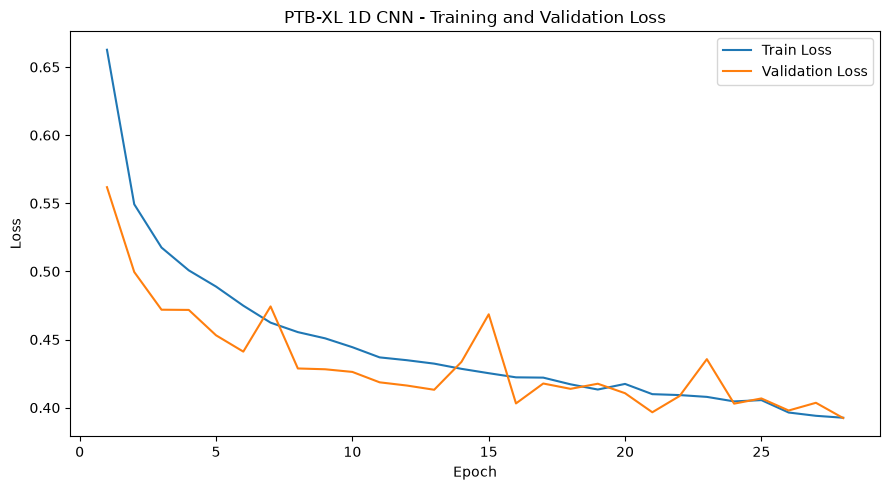

In [34]:

history_df = pd.DataFrame(history)

display(history_df)

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "PTB-XL 1D CNN - Training and Validation Loss"
)

plt.legend()
plt.tight_layout()
plt.show()


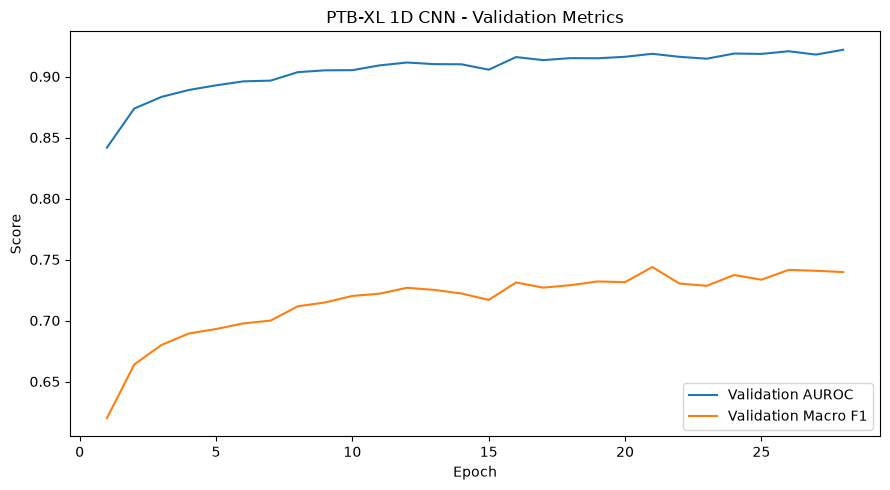

In [35]:

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["diagnostic_auroc"],
    label="Validation AUROC",
)

plt.plot(
    history_df["epoch"],
    history_df["diagnostic_f1"],
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(
    "PTB-XL 1D CNN - Validation Metrics"
)

plt.legend()
plt.tight_layout()
plt.show()


In [36]:

# Re-run validation inference using the final best model and
# optimize thresholds ONLY on the validation set.

validation_outputs = collect_predictions(
    model,
    val_loader,
)

diagnostic_thresholds, validation_threshold_f1 = (
    find_optimal_thresholds(
        validation_outputs["diagnostic_true"],
        validation_outputs["diagnostic_prob"],
    )
)

threshold_df = pd.DataFrame({
    "label": diagnostic_targets,
    "threshold": diagnostic_thresholds,
    "validation_F1": validation_threshold_f1,
})

display(threshold_df)


,label,threshold,validation_F1
0,NORM,0.48,0.858291
1,MI,0.43,0.735270
2,STTC,0.55,0.774823
3,CD,0.41,0.748707
4,HYP,0.53,0.602076


In [39]:

CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "cnn1d_best.pt"
)

checkpoint = {
    "model_state_dict": model.state_dict(),

    "model_config": MODEL_CONFIG,

    "train_config": TRAIN_CONFIG,

    "loss_config": LOSS_CONFIG,

    "augmentation_config": AUGMENTATION_CONFIG,

    "preprocessing_version":
        PREPROCESSING_VERSION,

    "preprocessing_config":
        preprocessing_config,

    "num_leads": NUM_LEADS,

    "signal_length": SIGNAL_LENGTH,

    "diagnostic_targets":
        diagnostic_targets,

    "diagnostic_thresholds":
        diagnostic_thresholds,

    "best_epoch":
        best_epoch,

    "best_validation_f1":
        best_validation_f1,

    "seed": SEED,
}

torch.save(
    checkpoint,
    CHECKPOINT_PATH,
)

print(
    "Saved CNN checkpoint:",
    CHECKPOINT_PATH,
)


Saved CNN checkpoint: d:\College Material\Major Project\CardioFusion-XAI\ml-service\checkpoints\ecg\ptbxl\cnn1d_best.pt


In [38]:

HISTORY_PATH = (
    RESULTS_DIR
    / "cnn1d_training_history.csv"
)

THRESHOLD_PATH = (
    RESULTS_DIR
    / "cnn1d_validation_thresholds.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)

threshold_df.to_csv(
    THRESHOLD_PATH,
    index=False,
)

print("Saved:")
print(HISTORY_PATH)
print(THRESHOLD_PATH)


Saved:
d:\College Material\Major Project\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\cnn1d_training_history.csv
d:\College Material\Major Project\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\100hz_record_zscore\cnn1d_validation_thresholds.csv


## Training complete

The trained model is saved as:

`checkpoints/ecg/ptbxl/cnn1d_best.pt`

The evaluation notebook loads this checkpoint and evaluates the untouched
PTB-XL test set using thresholds selected from the validation set only.
